In [ ]:
# install dependencies, in case needed
'''
!pip install pytorch-lightning
!pip install scikit-image
!pip install imagecodecs
!pip install torchmetrics
'''

'\n!pip install pytorch-lightning\n!pip install scikit-image\n!pip install imagecodecs\n!pip install torchmetrics\n'

In [ ]:
!pip install imagecodecs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 MB 12.4 MB/s eta 0:00:00


In [ ]:
!pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 51.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink

# 0 - Import Packages and Define Helper Functions

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import skimage.io
import scipy.ndimage
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision.transforms import Compose
from torch.autograd import Function
from skimage.transform import resize


In [2]:
#Setting random seeds for reproducable results
random_seed = 1
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.backends.cudnn.deterministic = True

#Setting the device on which the U-Net runs
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Network will run on "{device}".')

def plot_images(*args):
    f,ax = plt.subplots(1,len(args), figsize = (20,20))
    for i in range(len(args)):
        ax[i].imshow(args[i][0], cmap='gray')
        ax[i].set_title(args[i][1])
        ax[i].axis('off')
    plt.show()

def plot_images1(*args):
    f,ax = plt.subplots(3,3, figsize = (20,20),dpi=300)
    for i ,ax in enumerate(ax.flat):
        ax.imshow(args[i][0], cmap='gray')
        ax.set_title(args[i][1], fontsize=20)
        ax.axis('off')
    plt.show()
def plot_results(*args):
    for i in range(len(args)):
        plt.plot(args[i][0], label=args[i][1])

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

Network will run on "cuda".


# 1 - Data

In [3]:
import re
import io
import zipfile
from pathlib import Path

import requests

def create_url(mode, dataset):
    """
    Construct URL of CTC dataset.

    CTC datasets have a train and test dataset for each image sequence.
    """
    m = mode + "ing" if mode == "train" else mode
    return f"http://data.celltrackingchallenge.net/{m}-datasets/{dataset}.zip"

def download_dataset(base_dir, dataset_name, mode="train"):
    """
    Download and extract CTC dataset.
    """
    # setup paths
    data_dir = base_dir / mode
    dataset_dir = data_dir / dataset_name

    # check if data was already downloaded
    if dataset_dir.exists():
        print(f"Dataset {dataset_name} already exists.")
    else:
        # if data was not downloaded, yet, create folder it will be saved to and CTC url
        dataset_dir.mkdir(parents=True)
        download_url = create_url(mode, dataset_name)

        # download data and check that URL actually exists
        print(f"Downloading {mode} data from {dataset_name} ({download_url}) to {dataset_dir}/{dataset_name}.")
        r = requests.get(download_url)
        assert r.status_code == 200

        # extract zip file to data folder
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall(data_dir)

    print("Download finished.")
    return dataset_dir

In [4]:
base_dir = Path("dataset")
# download_dataset returns the name of the directory, the data was downloaded to
Fluo_Dir = download_dataset(base_dir, 'Fluo-N2DL-HeLa')
DIC_Dir = download_dataset(base_dir, 'DIC-C2DH-HeLa')
PHC_Dir = download_dataset(base_dir, 'PhC-C2DH-U373')

def sample_frames(frames, n, random_seed):
    rng = np.random.default_rng(random_seed)
    return tuple(rng.choice(frames, n, replace=False))


def create_dataset(
    dataset_dir, sequence, suffix="ST", n=None, random_seed=11, min_cells=0, ignore = None,NoDownload=False
):
    """
    Load images and masks from a dataset directory.

    Loads n randomly selected images from a given sequence of a CTC dataset.
    """
    # create directory names
    img_dir = dataset_dir / sequence
    msk_dir = dataset_dir / f"{sequence}_{suffix}" / "SEG"
    if suffix == "ERR_SEG":
        msk_dir = msk_dir.parent
    # find out which frames have provided masks
    min_cells = min_cells or 0
    ignore = ignore or []
    frames = [
        re.search(r"\d{3}$", fp.stem).group()
        for fp in sorted(msk_dir.glob("*.tif"))
        if len(np.unique(skimage.io.imread(fp))) > min_cells
    ]

    if ignore is not None:
        frames = np.setdiff1d(frames, ignore)

    # use all available frames or randomly sample n frames that should be used/loaded
    frames_sampled = (
        tuple(frames)
        if (n is None) or (n > len(frames))
        else sample_frames(frames, n, random_seed)
    )

    # print info on the data that will be loaded
    if (n is not None) and (n > len(frames)):
        print(
            f"Number of requested frames ({n}) exceeds the number of frames in sequence ({len(frames)}). Loading all {len(frames)} frames."
        )
    elif n is not None:
        print(
            f"Loading {len(frames_sampled)} / {len(frames)} images from sequence {sequence} of {dataset_dir.name}."
        )
        print(f"Loaded frames {sorted(frames_sampled)}")
    elif n is None:
        print(
            f"Loading {len(frames_sampled)} / {len(frames)} images from sequence {sequence} of {dataset_dir.name}."
        )
        print(f"Loaded frames {sorted(frames_sampled)}")

    # load images and masks
    images = [
        skimage.io.imread(fp)
        for fp in sorted(img_dir.glob("*.tif"))
        if fp.stem.endswith(frames_sampled)
    ]
    masks = [
        skimage.io.imread(fp)
        for fp in sorted(msk_dir.glob("*.tif"))
        if fp.stem.endswith(frames_sampled)
    ]

    return np.stack(images), np.stack(masks), frames_sampled




Dataset Fluo-N2DL-HeLa already exists.
Download finished.
Dataset DIC-C2DH-HeLa already exists.
Download finished.
Dataset PhC-C2DH-U373 already exists.
Download finished.


In [5]:
Fluo_GT_x_01, Fluo_GT_y_01, Fluo_GT_frames_val_01 = create_dataset(Fluo_Dir, "01", suffix="GT")
Fluo_ST_x_01, Fluo_ST_y_01, _ = create_dataset(Fluo_Dir, "01", suffix="ST", ignore = Fluo_GT_frames_val_01)
Fluo_GT_x_02, Fluo_GT_y_02, Fluo_GT_frames_val_02 = create_dataset(Fluo_Dir, "02", suffix="GT")
Fluo_ST_x_02, Fluo_ST_y_02, _ = create_dataset(Fluo_Dir, "02", suffix="ST", ignore = Fluo_GT_frames_val_02)

DIC_GT_x_01, DIC_GT_y_01, DIC_GT_frames_val_01 = create_dataset(DIC_Dir, "01", suffix="GT")
DIC_ST_x_01, DIC_ST_y_01, _ = create_dataset(DIC_Dir, "01", suffix="ST", ignore = DIC_GT_frames_val_01)
DIC_GT_x_02, DIC_GT_y_02, DIC_GT_frames_val_02 = create_dataset(DIC_Dir, "02", suffix="GT")
DIC_ST_x_02, DIC_ST_y_02, _ = create_dataset(DIC_Dir, "02", suffix="ST", ignore = DIC_GT_frames_val_02)

PHC_GT_x_01, PHC_GT_y_01, PHC_GT_frames_val_01 = create_dataset(PHC_Dir, "01", suffix="GT")
PHC_ST_x_01, PHC_ST_y_01, _ = create_dataset(PHC_Dir, "01", suffix="ST", ignore = PHC_GT_frames_val_01)
PHC_GT_x_02, PHC_GT_y_02, PHC_GT_frames_val_02 = create_dataset(PHC_Dir, "02", suffix="GT")
PHC_ST_x_02, PHC_ST_y_02, _ = create_dataset(PHC_Dir, "02", suffix="ST", ignore = PHC_GT_frames_val_02)

Loading 28 / 28 images from sequence 01 of Fluo-N2DL-HeLa.
Loaded frames ['012', '013', '014', '015', '020', '021', '022', '023', '025', '029', '038', '039', '040', '044', '050', '051', '052', '053', '054', '055', '062', '076', '077', '078', '079', '080', '081', '088']
Loading 64 / 64 images from sequence 01 of Fluo-N2DL-HeLa.
Loaded frames ['000', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '016', '017', '018', '019', '024', '026', '027', '028', '030', '031', '032', '033', '034', '035', '036', '037', '041', '042', '043', '045', '046', '047', '048', '049', '056', '057', '058', '059', '060', '061', '063', '064', '065', '066', '067', '068', '069', '070', '071', '072', '073', '074', '075', '082', '083', '084', '085', '086', '087', '089', '090', '091']
Loading 8 / 8 images from sequence 02 of Fluo-N2DL-HeLa.
Loaded frames ['023', '035', '036', '067', '075', '078', '079', '087']
Loading 84 / 84 images from sequence 02 of Fluo-N2DL-HeLa.
Loaded frames ['000',

# 2 - Data Slicing and Augmentation

In [6]:
def get_slices(dataset_shape, patch_size, stride):
    x, y = dataset_shape
    p_x, p_y = patch_size
    s_x, s_y = stride

    #Generate indices in x-direction
    x_indices = np.arange(0, x - p_x + 1, s_x)
    if x_indices[-1] + p_x < x:
        x_indices = np.append(x_indices, x - p_x)

    #Generate indices in y-direction
    y_indices = np.arange(0, y - p_y + 1, s_y)
    if y_indices[-1] + p_y < y:
        y_indices = np.append(y_indices, y - p_y)

    slices = []
    for idx_x in x_indices:
        for idx_y in y_indices:
            slices.append((
                slice(idx_x, idx_x + p_x),
                slice(idx_y, idx_y + p_y)
            ))
    return(slices)

In [7]:
class ToFloat():
    def __call__(self, x):
        return(x.astype(np.float32))

class ToTensor():
    def __call__(self, x):
        if len(x.shape) == 2:
            return(torch.from_numpy(x.copy()).unsqueeze(0))
        elif len(x.shape) == 3:
            return(torch.from_numpy(x.copy()))


class Normalize():
    def __init__(self, min=None, max =None, eps=1e-8):
        self.min = min
        self.max = max
        self.eps = eps

    def __call__(self, x):
            return(((x - x.min()) / (x.max() - x.min() + self.eps))*255)


#When visualizing the data, we saw that the
#ground truth contains instance segmentation masks.
#This class transforms them into a binary mask
#which can be used for foreground/background segmentation
class Instance2Semantic():
    def __call__(self, x):
        return((x > 0).astype(int))

from scipy.ndimage import rotate

class RandomFlip():
    def __init__(self, random_state, execution_probability=0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability
    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            axis = self.random_state.choice([0, 1])
            x = np.flip(x, axis=axis)
            pass
        return(x)

class RandomRotate():
    def __init__(self, random_state, angle_range, execution_probability=0.0, mode='mirror', order=0, reshape=False):
        self.random_state = random_state
        self.angle_range = angle_range #This is a list specifing the angle range, i.e. [angle_min, angle_max]
        self.execution_probability = execution_probability
        self.mode = mode
        self.order = order
        self.reshape = reshape

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            angle = self.random_state.uniform(self.angle_range[0], self.angle_range[1])
            x = rotate(
                x,
                angle=angle,
                axes=(1, 0),  # rotate in (y, x) plane
                reshape=self.reshape,
                order=self.order,
                mode=self.mode
            )
            pass
        return(x)

class RandomRotate90():
    def __init__(self, random_state, execution_probability=0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            k = self.random_state.randint(1,4)
            return(np.rot90(x,k))
        return(x)

class RandomContrast():
    def __init__(self, random_state, scale, execution_probability=0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability
        self.scale = scale
    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            lam = self.random_state.uniform(np.max((0, 1 - self.scale)), 1 + self.scale)
            return(np.clip(x * lam, 0, 255))
        return(x)

class RandomBrightness():
    def __init__(self,random_state, scale, execution_probability=0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability
        self.scale = scale
    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            lam = 255 * self.scale * self.random_state.uniform(-1,1)
            return(np.clip(x + lam, 0, 255))
        return(x)

class RandomElasticDeformation():
    def __init__(self, random_state, grid_size, sigma, order, execution_probability=0.0):
        self.random_state = random_state
        self.grid_size = grid_size
        self.sigma = sigma
        self.order = order
        self.execution_probability = execution_probability

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            h,w = x.shape

            dx = self.random_state.randn(*[self.grid_size, self.grid_size]) * self.sigma
            dy = self.random_state.randn(*[self.grid_size, self.grid_size]) * self.sigma

            dx = resize(dx, x.shape, preserve_range=True, order = 3)
            dy = resize(dy, x.shape, preserve_range=True, order = 3)

            idx_x, idx_y = np.meshgrid(np.arange(h), np.arange(w))

            coordinates = idx_y + dy, idx_x + dx

            return(scipy.ndimage.map_coordinates(x, coordinates, order = self.order, mode = 'reflect', prefilter=False))
        return(x)



# 3 - 2D U-Net Components

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, ch_in, ch_out, kernel_size, padding, pooling, dropout):
        super(EncoderLayer, self).__init__()
        if pooling:
            self.pooling = nn.MaxPool2d(2)
        else:
            self.pooling = None
        self.block = nn.Sequential(
            nn.Conv2d(ch_in, ch_out, kernel_size=kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(ch_out, track_running_stats=True),
            nn.ReLU(),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
            nn.Conv2d(ch_out, ch_out, kernel_size=kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(ch_out, track_running_stats=True),
            nn.ReLU(),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        )

    def forward(self,x):
        if self.pooling is not None:
            x = self.pooling(x)
        x = self.block(x)
        return(x)


class DecoderLayer(nn.Module):
    def __init__(self, ch_in, ch_out, kernel_size, padding, dropout, skip_mode='concat', upsampling_mode='transpose', cropping=False):
        super(DecoderLayer, self).__init__()

        assert upsampling_mode in ['transpose', 'interpolate'], f'Upsampling has to be either "transpose" or "interpolate" but got "{upsampling_mode}"'
        assert skip_mode in ['concat', 'add', 'none'], f'Skip-connection has to be either "none", "add" or "concat" but got "{skip_mode}"'

        self.cropping = cropping
        self.skip_mode = skip_mode
        self.upsampling_mode = upsampling_mode

        if self.upsampling_mode == 'transpose':
            self.up = nn.ConvTranspose2d(ch_in, ch_out, kernel_size=2, stride = 2)
        else:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            #1x1 convolution equalizes the number of channels
            self.conv = nn.Conv2d(ch_in, ch_out, kernel_size=1, stride=1, padding=0)

        if self.skip_mode == 'concat':
            ch_hidden = ch_out + ch_out
        elif self.skip_mode == 'add':
            ch_hidden = ch_out
        elif self.skip_mode == 'none':
            ch_hidden = ch_out

        self.block = nn.Sequential(
            nn.Conv2d(ch_hidden, ch_out, kernel_size=kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(ch_out, track_running_stats=True),
            nn.ReLU(),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
            nn.Conv2d(ch_out, ch_out, kernel_size=kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(ch_out, track_running_stats=True),
            nn.ReLU(),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        )

    def crop(self, x, cropping_size):
        return(x[:,:,cropping_size[0]:-cropping_size[0], cropping_size[1]:-cropping_size[1]])

    def forward(self,x, skip_features):
        if self.upsampling_mode == 'transpose':
            x = self.up(x)
        elif self.upsampling_mode == 'interpolate':
            x = self.up(x)
            x = self.conv(x)

        if self.cropping:
            cropping_size = (torch.tensor(skip_features.shape[2:]) - torch.tensor(x.shape[2:]))//2
            skip_features = self.crop(skip_features, cropping_size)

        if self.skip_mode == 'concat':
            x = self.block(torch.cat((x, skip_features), 1))
        elif self.skip_mode == 'add':
            x = self.block(x + skip_features)
            pass
        elif self.skip_mode == 'none':
            pass

        return(x)

U-Net Architecture

In [9]:
class UNet2d(nn.Module):
    def __init__(self,
                 input_dim,
                 output_dim,
                 encoder_layer=EncoderLayer,
                 decoder_layer=DecoderLayer,
                 hidden_dims=[64,128,256,512,1024],
                 kernel_size=3,
                 padding_mode='valid',
                 skip_mode='concat',
                 upsampling_mode='transpose',
                 dropout=0,
                 num_domains=3
                 ):

        super(UNet2d, self).__init__()

        assert len(hidden_dims) > 0, 'UNet2d requires at least one hidden layer'
        assert padding_mode in ['same', 'valid'], f'Padding mode has to be either "same" or "valid" but got "{padding_mode}"'

        self.padding_mode = padding_mode

        cropping = True if padding_mode == 'valid' else False
        padding = 0 if padding_mode == 'valid' else kernel_size//2

        #Assembling the encoder
        encoder = []
        for i in range(len(hidden_dims)):
            if i == 0:
                ch_in = input_dim
                ch_out = hidden_dims[i]
                encoder.append(encoder_layer(ch_in, ch_out, kernel_size=kernel_size, padding=padding, pooling=False, dropout=0))
            elif i == (len(hidden_dims) - 1):
                ch_in = hidden_dims[i-1]
                ch_out = hidden_dims[i]
                encoder.append(encoder_layer(ch_in, ch_out, kernel_size=kernel_size, padding=padding, pooling=True, dropout=dropout))
            else:
                ch_in = hidden_dims[i-1]
                ch_out = hidden_dims[i]
                encoder.append(encoder_layer(ch_in, ch_out, kernel_size=kernel_size, padding=padding, pooling=True, dropout=0))
        self.encoder = nn.ModuleList(encoder)

        #Assembling the decoder
        decoder = []

        #Reversing the order of the hidden dims, since the decoder reduces the number of channels
        hidden_dims_rev = hidden_dims[::-1]

        for i in range(len(hidden_dims_rev) - 1):
            ch_in = hidden_dims_rev[i]
            ch_out = hidden_dims_rev[i+1]
            decoder.append(decoder_layer(ch_in, ch_out, kernel_size=kernel_size, padding=padding, dropout=0, skip_mode=skip_mode, upsampling_mode=upsampling_mode, cropping=cropping))
        self.decoder = nn.ModuleList(decoder)

        #Creating final 1x1 convolution
        self.final_conv = nn.Conv2d(hidden_dims[0], output_dim, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        #Forward pass of the encoder
        skip_features = []
        for encoder_layer in self.encoder:
            x = encoder_layer(x)
            skip_features.insert(0, x)
        bottleneck=x
        #Removing bottleneck features from the feature list
        skip_features = skip_features[1:]

        #Forward pass of the decoder
        for i, decoder_layer in enumerate(self.decoder):
            skip = skip_features[i]
            x = decoder_layer(x, skip)

        #Performing the final 1x1 convolution
        x = self.final_conv(x)

        return(x)


def weights_init(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
    if isinstance(m, nn.ConvTranspose2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')

def kaiming_init_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Linear, nn.Conv2d,nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

# 4 - Training, Validation and Testing

## Defining Parameters

In [34]:
#Training of the original U-Net

#Network parameters
input_channel = 1
output_channel = 2
hidden_dims = [32,64,128,256,512]
kernel_size = 3
padding_mode = 'valid'                  # possible padding modes: 'same', 'valid'
skip_mode = 'concat'                    # possible skip modes: 'none', 'add', 'concat'
upsampling_mode = 'transpose'           # possible upsampling modes: 'interpolate', 'transpose'
dropout = 0.2                         # note: dropout is only applied to the bottleneck features
encoder_layer = EncoderLayer
decoder_layer = DecoderLayer

#Dataset parameters
batch_size = 8
patch_size_original_train = [460,460]   # patches cannot be larger than the image itself
stride_original_train = [52,52]      # stride should be smaller than the patches
padding_original_train = [0,0]          # when using 'valid' convolution, padding can be used to cope with the border problem

#Training parameters
learning_rate = 1e-3

#Dataset choosing
num_fluo = 2
num_dic = 40
num_phc = 9
dice_ratio = 0.5
domain_loss_ratio = 0

execution_probability = 0.7 #Probability that augmentations will be applied to the images

#Test setting
patch_size_original_test= [460,460]
stride_original_test = [52,52]
padding_original_test = [200,200]



In [35]:
#Defining the transformations and augmentations for the training images and labels.

image_transforms_train = Compose([
    ToFloat(),
    Normalize(),
    RandomRotate90(random_state=np.random.RandomState(random_seed), execution_probability=execution_probability),
    RandomRotate(random_state=np.random.RandomState(random_seed), angle_range=[-15,15], execution_probability=execution_probability, order=2),
    RandomFlip(random_state=np.random.RandomState(random_seed), execution_probability=execution_probability),
    RandomElasticDeformation(random_state=np.random.RandomState(random_seed), grid_size=3, sigma=10, order=3, execution_probability=execution_probability),
    RandomContrast(random_state=np.random.RandomState(random_seed), scale=0.1, execution_probability=execution_probability),
    RandomBrightness(random_state=np.random.RandomState(random_seed), scale=0.1, execution_probability=execution_probability),
    ToTensor()
])
label_transforms_train = Compose([
    Instance2Semantic(),
    RandomRotate90(random_state=np.random.RandomState(random_seed), execution_probability=execution_probability),
    RandomRotate(random_state=np.random.RandomState(random_seed), angle_range=[-15,15], execution_probability=execution_probability, order=2),
    RandomFlip(random_state=np.random.RandomState(random_seed), execution_probability=execution_probability),
    RandomElasticDeformation(random_state=np.random.RandomState(random_seed), grid_size=3, sigma=10, order=3, execution_probability=execution_probability),
    ToTensor()
])



#Defining the transformations and augmentations for the validation images and labels.
image_transforms_val = Compose([
    ToFloat(),
    Normalize(),
    ToTensor()
])
label_transforms_val = Compose([
    Instance2Semantic(),
    ToTensor()
])



#Defining the transformations and augmentations for the test images and labels.
image_transforms_test = Compose([
    ToFloat(),
    Normalize(),
    ToTensor()
])
label_transforms_test = Compose([
    Instance2Semantic(),
    ToTensor()
])


## Loss Function, Dataset and Trainer

In [36]:
import torch
import torch.nn.functional as F

def Dice(pred, gt):
    numerator = 2 * np.sum(pred * gt, axis = (1,2))
    denominator = np.sum(pred, axis = (1,2)) + np.sum(gt, axis = (1,2))
    return(np.mean(numerator / denominator))

def IoU(pred, gt):
    numerator = np.sum(pred * gt, axis = (1,2))
    denominator = np.sum(pred, axis = (1,2)) + np.sum(gt, axis = (1,2)) - np.sum(pred * gt, axis = (1,2))
    return(np.mean(numerator / denominator))

def dice_loss(output, target, smooth=1e-6):
    """
    output: Tensor of shape (B, 2, H, W) - logits
    target: Tensor of shape (B, 1, H, W) - class indices (0 or 1)
    Returns:
        scalar dice loss (float tensor)
    """
    # Apply softmax to get class probabilities
    probs = F.softmax(output, dim=1)  # shape: (B, 2, H, W)
    # We only use class 1 for Dice (foreground)
    probs_fg = probs[:, 1, :, :]  # shape: (B, H, W)
    target_fg = (target == 1).float().squeeze(1)  # shape: (B, H, W)
    # Flatten for each batch item
    probs_fg = probs_fg.view(probs_fg.size(0), -1)
    target_fg = target_fg.view(target_fg.size(0), -1)
    intersection = (probs_fg * target_fg).sum(dim=1)
    union = probs_fg.sum(dim=1) + target_fg.sum(dim=1)
    dice = (2. * intersection + smooth) / (union + smooth)
    loss = 1 - dice.mean()
    return loss

def dice_loss_multiclass(output, target, smooth=1e-6):
    """
    output: Tensor of shape (B, C, H, W) - logits
    target: Tensor of shape (B, 1, H, W) - class indices
    """
    num_classes = output.shape[1]
    probs = F.softmax(output, dim=1)  # (B, C, H, W)
    target_one_hot = F.one_hot(target.squeeze(1).long(), num_classes)  # (B, H, W, C)
    target_one_hot = target_one_hot.permute(0, 3, 1, 2).float()  # (B, C, H, W)

    # Flatten
    probs = probs.view(probs.size(0), num_classes, -1)
    target_one_hot = target_one_hot.view(target_one_hot.size(0), num_classes, -1)

    intersection = (probs * target_one_hot).sum(dim=2)
    union = probs.sum(dim=2) + target_one_hot.sum(dim=2)
    dice = (2. * intersection + smooth) / (union + smooth)

    return 1 - dice.mean()

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, output, target):
        """
        output: (B, 2, H, W) - logits
        target: (B, 1, H, W) - 0 or 1
        """
        # Step 1: Flatten
        B, C, H, W = output.shape
        output = output.permute(0, 2, 3, 1).reshape(-1, C)       # (B*H*W, 2)
        target = target.reshape(-1).long()
                          # (B*H*W,)

        # Step 2: Compute log probabilities
        log_probs = F.log_softmax(output, dim=1)                 # (B*H*W, 2)
        probs = torch.exp(log_probs)                             # (B*H*W, 2)

        # Step 3: Gather the probs for the target class
        log_pt = log_probs[torch.arange(len(target)), target]    # (B*H*W,)
        pt = probs[torch.arange(len(target)), target]            # (B*H*W,)

        # Step 4: Focal Loss
        focal_term = (1 - pt) ** self.gamma
        loss = -self.alpha * focal_term * log_pt

        # Step 5: Reduction
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss  # no reduction

def Mixed_Loss(output, target, dice_ratio,smooth=1e-6):
    ce_loss = nn.CrossEntropyLoss()
    ce_value=ce_loss(output, target[:,0].long())
    return(dice_ratio*dice_loss(output, target, smooth=1e-6)+(1-dice_ratio)*ce_value)


In [37]:
class UNetDataset(Dataset):
    def __init__(self,
                 image,
                 label,
                 patch_size,
                 stride,
                 padding,
                 image_transformer,
                 label_transformer,
                 phase,
                 domain
                 ):


        self.phase = phase
        self.domain = domain
        self.image_transformer = image_transformer
        self.label_transformer = label_transformer

        self.image = image
        self.label = label

        self.image_shape = self.image.shape
        if padding is not None:
            self.image = np.pad(self.image, pad_width=((padding[0], padding[0]), (padding[1], padding[1])), mode='reflect')
            self.label = np.pad(self.label, pad_width=((padding[0], padding[0]), (padding[1], padding[1])), mode='reflect')

        self.slices = get_slices(self.image.shape, patch_size, stride)


    def __len__(self,):
        return(len(self.slices))

    def __getitem__(self, index):
        sl = self.slices[index]

        x = self.image[sl]
        y = self.label[sl]

        x = self.image_transformer(x)
        y = self.label_transformer(y)
        domain_label=self.domain
        if self.phase == 'test':
            return(x, y, sl,domain_label)
        else:
            return(x, y,domain_label)

#This function is needed to form the batch from a list of samples
def custom_collate(batch):
    if isinstance(batch[0], torch.Tensor):
        return(torch.stack(batch, 0))
    elif isinstance(batch[0], slice):
        return(batch)
    elif isinstance(batch[0], tuple):
        return([custom_collate(obj) for obj in zip(*batch)])
    elif isinstance(batch[0], (int, float)):
        return torch.tensor(batch)



def get_dataloader(x, y, batch_size, patch_size, stride, padding, image_transforms, label_transforms, phase,domain):
    assert phase in ['train', 'validate', 'test'], f'Phase has to be either "train", "validate" or "test" but got "{phase}"'
    shuffle = True if phase == 'train' else False
    data = []
    for i in range(x.shape[0]):
        dataset = UNetDataset(x[i], y[i], patch_size, stride,padding, image_transforms, label_transforms, phase,domain)
        data.append(dataset)
    dataloader = DataLoader(dataset=ConcatDataset(data), batch_size=batch_size, shuffle=shuffle, num_workers=0, collate_fn=custom_collate)
    return(dataloader)

def get_croppeddata(x, y, batch_size, patch_size, stride, padding, image_transforms, label_transforms, phase,domain):
    assert phase in ['train', 'validate', 'test'], f'Phase has to be either "train", "validate" or "test" but got "{phase}"'
    shuffle = True if phase == 'train' else False
    data = []
    for i in range(x.shape[0]):
        dataset = UNetDataset(x[i], y[i], patch_size, stride,padding, image_transforms, label_transforms, phase,domain)
        data.append(dataset)
    return(data)

## Define Dataset

Here you define the dataset and dataloader, decide how many images from each microscope image set would be used for training and validation.

In [38]:
from sklearn.model_selection import train_test_split
from torch.utils.data import random_split

# My strategy of defining the dataset here: using different numbers of images from each set because of different size
'''The Overview of the datasets:
Dataset ImageSize   GT_number   All_number  croppeddata_train[0]_460  croppeddata_val[0]_332
DIC     512*512     9           84          4                         9
Fluo    1100*700    28          92          32                        28
PhC     696x520     15          115         8                         12
'''

indices_Fluo = np.random.choice(Fluo_ST_x_01.shape[0], num_fluo, replace=False)
indices_DIC = np.random.choice(DIC_ST_x_01.shape[0], num_dic, replace=False)
indices_PHC = np.random.choice(PHC_ST_x_01.shape[0], num_phc, replace=False)

x_Fluo_dataset=np.concatenate([Fluo_ST_x_01], axis=0)[indices_Fluo]
x_DIC_dataset=np.concatenate([DIC_GT_x_01,DIC_ST_x_01], axis=0)[indices_DIC]
x_PHC_dataset=np.concatenate([PHC_GT_x_01,PHC_ST_x_01], axis=0)[indices_PHC]

y_Fluo_dataset=np.concatenate([Fluo_ST_y_01], axis=0)[indices_Fluo]
y_DIC_dataset=np.concatenate([DIC_GT_y_01,DIC_ST_y_01], axis=0)[indices_DIC]
y_PHC_dataset=np.concatenate([PHC_GT_y_01,PHC_ST_y_01], axis=0)[indices_PHC]

'''
x_Fluo_train_dataset, x_Fluo_val_dataset, y_Fluo_train_dataset, y_Fluo_val_dataset = train_test_split(x_Fluo_dataset, y_Fluo_dataset, test_size=1/6, random_state=42)
x_DIC_train_dataset, x_DIC_val_dataset, y_DIC_train_dataset, y_DIC_val_dataset = train_test_split(x_DIC_dataset, y_DIC_dataset, test_size=1/6, random_state=42)
x_PHC_train_dataset, x_PHC_val_dataset, y_PHC_train_dataset, y_PHC_val_dataset = train_test_split(x_PHC_dataset, y_PHC_dataset, test_size=1/6, random_state=42)

Fluo_croppeddata_train = get_croppeddata(x=x_Fluo_train_dataset, y=y_Fluo_train_dataset, batch_size=batch_size, patch_size=patch_size_original_train, stride=stride_original_train, padding=padding_original_train, image_transforms=image_transforms_train, label_transforms=label_transforms_train, phase='train')
DIC_croppeddata_train = get_croppeddata(x=x_DIC_train_dataset, y=y_DIC_train_dataset, batch_size=batch_size, patch_size=patch_size_original_train, stride=stride_original_train, padding=padding_original_train, image_transforms=image_transforms_train, label_transforms=label_transforms_train, phase='train')
PHC_croppeddata_train = get_croppeddata(x=x_PHC_train_dataset, y=y_PHC_train_dataset, batch_size=batch_size, patch_size=patch_size_original_train, stride=stride_original_train, padding=padding_original_train, image_transforms=image_transforms_train, label_transforms=label_transforms_train, phase='train')

Fluo_croppeddata_val = get_croppeddata(x=x_Fluo_val_dataset, y=y_Fluo_val_dataset, batch_size=batch_size, patch_size=patch_size_original_train, stride=stride_original_train, padding=padding_original_train, image_transforms=image_transforms_val, label_transforms=label_transforms_val, phase='validate')
DIC_croppeddata_val = get_croppeddata(x=x_DIC_val_dataset, y=y_DIC_val_dataset, batch_size=batch_size, patch_size=patch_size_original_train, stride=stride_original_train, padding=padding_original_train, image_transforms=image_transforms_val, label_transforms=label_transforms_val, phase='validate')
PHC_croppeddata_val = get_croppeddata(x=x_PHC_val_dataset, y=y_PHC_val_dataset, batch_size=batch_size, patch_size=patch_size_original_train, stride=stride_original_train, padding=padding_original_train, image_transforms=image_transforms_val, label_transforms=label_transforms_val, phase='validate')
'''
'''

dataloader_train = DataLoader(dataset=ConcatDataset(Fluo_croppeddata_train+DIC_croppeddata_train+PHC_croppeddata_train), batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=custom_collate)
dataloader_val = DataLoader(dataset=ConcatDataset(Fluo_croppeddata_val+DIC_croppeddata_val+PHC_croppeddata_val), batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=custom_collate)
'''
#domain label: Fluo 0, DIC 1, PHC 2

Fluo_croppeddata = get_croppeddata(x=x_Fluo_dataset, y=y_Fluo_dataset, batch_size=batch_size, patch_size=patch_size_original_train, stride=stride_original_train, padding=padding_original_train, image_transforms=image_transforms_train, label_transforms=label_transforms_train, phase='train',domain=0)
DIC_croppeddata = get_croppeddata(x=x_DIC_dataset, y=y_DIC_dataset, batch_size=batch_size, patch_size=patch_size_original_train, stride=stride_original_train, padding=padding_original_train, image_transforms=image_transforms_train, label_transforms=label_transforms_train, phase='train',domain=1)
PHC_croppeddata = get_croppeddata(x=x_PHC_dataset, y=y_PHC_dataset, batch_size=batch_size, patch_size=patch_size_original_train, stride=stride_original_train, padding=padding_original_train, image_transforms=image_transforms_train, label_transforms=label_transforms_train, phase='train', domain=2)

generator=torch.Generator().manual_seed(42)

#train_to_split=ConcatDataset(Fluo_croppeddata+DIC_croppeddata+PHC_croppeddata)
train_to_split=ConcatDataset(Fluo_croppeddata+DIC_croppeddata+PHC_croppeddata)

train_size=int(0.9*len(train_to_split))
val_size=len(train_to_split)-train_size

train_dataset, val_dataset = random_split(train_to_split, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

dataloader_train = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=custom_collate)
dataloader_val = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=custom_collate)




In [39]:
print(len(Fluo_croppeddata[0]))
print(len(DIC_croppeddata[0]))
print(len(PHC_croppeddata[0]))

84
4
18


In [40]:
len(Fluo_croppeddata)

2

In [41]:
unet = UNet2d(input_channel,output_channel,encoder_layer,decoder_layer, hidden_dims, kernel_size, padding_mode, skip_mode, upsampling_mode, dropout)

In [42]:
'''
#Preparing dataloader
dataloader_train = get_dataloader(x=x_train, y=y_train, batch_size=batch_size, patch_size=patch_size_original_train, stride=stride_original_train, padding=padding_original_train, image_transforms=image_transforms_train, label_transforms=label_transforms_train, phase='train')
dataloader_val = get_dataloader(x=x_val, y=y_val, batch_size=batch_size, patch_size=patch_size_original_train, stride=stride_original_train, padding=padding_original_train, image_transforms=image_transforms_val, label_transforms=label_transforms_val, phase='validate')

#Initializing the U-Net
unet = UNet2d(input_channel,output_channel,encoder_layer,decoder_layer, hidden_dims, kernel_size, padding_mode, skip_mode, upsampling_mode, dropout)
'''

"\n#Preparing dataloader\ndataloader_train = get_dataloader(x=x_train, y=y_train, batch_size=batch_size, patch_size=patch_size_original_train, stride=stride_original_train, padding=padding_original_train, image_transforms=image_transforms_train, label_transforms=label_transforms_train, phase='train')\ndataloader_val = get_dataloader(x=x_val, y=y_val, batch_size=batch_size, patch_size=patch_size_original_train, stride=stride_original_train, padding=padding_original_train, image_transforms=image_transforms_val, label_transforms=label_transforms_val, phase='validate')\n\n#Initializing the U-Net\nunet = UNet2d(input_channel,output_channel,encoder_layer,decoder_layer, hidden_dims, kernel_size, padding_mode, skip_mode, upsampling_mode, dropout)\n"

## Trainer Lightning

In [ ]:
import pytorch_lightning as pl
def get_lambda(p, gamma=10):
    return 2 / (1 + np.exp(-gamma * p)) - 1
class UNetLightning(pl.LightningModule):
    def __init__(self, model, loss_function_seg, lr=1e-3,domain_loss_ratio=domain_loss_ratio,dice_ratio=dice_ratio):
        super().__init__()
        self.save_hyperparameters()
        self.model = model
        self.lr = lr
        self.loss_function_seg=loss_function_seg
        self.domain_loss_ratio=domain_loss_ratio
        self.dice_ratio=dice_ratio

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        input, target,domain_label  = batch
        output = self.model(input)

        if self.model.padding_mode == 'valid':
                    cropping_size = (torch.tensor(input.shape[2:]) - torch.tensor(output.shape[2:]))//2
                    target = target[:,:,cropping_size[0]:-cropping_size[0], cropping_size[1]:-cropping_size[1]]

        loss_seg = self.loss_function_seg(output, target,self.dice_ratio)
        loss = loss_seg

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_loss_seg", loss_seg)
        return loss

    def validation_step(self, batch, batch_idx):
        self.model.eval()
        input, target,domain_label = batch
        output = self.model(input)
        if self.model.padding_mode == 'valid':
                cropping_size = (torch.tensor(input.shape[2:]) - torch.tensor(output.shape[2:]))//2
                target = target[:,:,cropping_size[0]:-cropping_size[0], cropping_size[1]:-cropping_size[1]]

        loss_seg = self.loss_function_seg(output, target,dice_ratio=self.dice_ratio)
        loss = loss_seg
        
        self.log("val_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), self.lr)
        scheduler = {
        'scheduler': torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=20, factor=0.1),
        'monitor': 'val_loss',
        'interval': 'epoch',
        'frequency': 1,
        }
        return {'optimizer': optimizer, 'lr_scheduler': scheduler}

In [44]:
kaiming_init_weights(unet)


In [45]:
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger

kaiming_init_weights(unet)


UnetLightningModel = UNetLightning(model=unet, loss_function_seg=Mixed_Loss,lr=1e-3,domain_loss_ratio=domain_loss_ratio,dice_ratio=dice_ratio)

UNetLightningTrainer = Trainer(
    max_epochs=30,
    accelerator="gpu" if torch.cuda.is_available()==True else "cpu",
    devices=1,
    log_every_n_steps=10
)
logger = TensorBoardLogger(save_dir="lightning_logs/")
UNetLightningTrainer.fit(UnetLightningModel, dataloader_train, dataloader_val)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type   | Params | Mode 
-----------------------------------------
0 | model | UNet2d | 7.8 M  | train
-----------------------------------------
7.8 M     Trainable params
0         Non-trainable params
7.8 M     Total params
31.062    Total estimated model params size (MB)
102       Modules in train mode
0         Modules in eval mode


Epoch 1:   9%|▉         | 5/56 [00:09<01:39,  0.51it/s, v_num=76, train_loss=0.219, val_loss=0.297] 


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [53]:
%load_ext tensorboard

In [56]:
%tensorboard --logdir=lightning_logs --port=60744
# If tensorboard doesn't work locally, put and open "localhost: + port" in your browser. Sometimes it's buggy and changing the port above works.


## Predict and Test

** By predict and test the ***original data images*** are processed, stitched, and Dice is calculated.

In [47]:
def unpad(img, padding_size):
    if len(img.shape) == 3:
        return(img[:,padding_size[0]:-padding_size[0], padding_size[1]:-padding_size[1]])
    else:
        return(img[padding_size[0]:-padding_size[0], padding_size[1]:-padding_size[1]])

def predict(model, x_test, y_test, patch_size, stride, padding, image_transforms, label_transforms,domain_label):
    model=model.to(device)
    dataloader = get_dataloader(x=x_test[None], y=y_test[None], batch_size=1, patch_size=patch_size, stride=stride, padding=padding, image_transforms=image_transforms, label_transforms=label_transforms, phase='test',domain=domain_label)
    image_size = dataloader.dataset.datasets[0].image_shape

    model.eval()

    padded_shape = (image_size[0] + 2 * padding[0], image_size[1] + 2 * padding[1])
    prediction = np.zeros((2,) + padded_shape)
    normalization = np.zeros(padded_shape)
    with torch.no_grad():
        for data in dataloader:
            input, _, current_patch_index,label = data

            input = input.to(device)

            output = model(input)


            for b in range(input.shape[0]):
                if input.shape[2] == output.shape[2] and input.shape[3] == output.shape[3]:
                    normalization[(current_patch_index[0][b], current_patch_index[1][b])] += 1
                    prediction[(slice(0,2,None),) + (current_patch_index[0][b], current_patch_index[1][b])] += output[b].detach().cpu().numpy()

                else:
                    cropping_size = (torch.tensor(input.shape[2:]) - torch.tensor(output.shape[2:]))//2
                    padded_index = (
                        slice(current_patch_index[0][b].start + cropping_size[0], current_patch_index[0][b].stop - cropping_size[0]),
                        slice(current_patch_index[1][b].start + cropping_size[1], current_patch_index[1][b].stop - cropping_size[1])
                    )
                    normalization[padded_index] += 1
                    prediction[(slice(0,2,None),) + padded_index] += output[b].detach().cpu().numpy()

    model.train()

    if padding[0] != 0 and padding[1] != 0:
        prediction = unpad(prediction, padding)
        normalization = unpad(normalization, padding)

    result = (prediction / normalization).argmax(0)

    eval_score_Dice = Dice(result[None], (y_test>0)[None])
    eval_score_IoU = IoU(result[None], (y_test>0)[None])


    return(result, eval_score_Dice,eval_score_IoU)

In [ ]:
UnetLightningModel = UNetLightning.load_from_checkpoint(r"E:\Studieren\University Heidelberg\SoSe25\Deeplife\project\lightning_logs\model 0.3 + gradient grl e30\checkpoints\epoch=29-step=1680.ckpt")
unet = UnetLightningModel.model

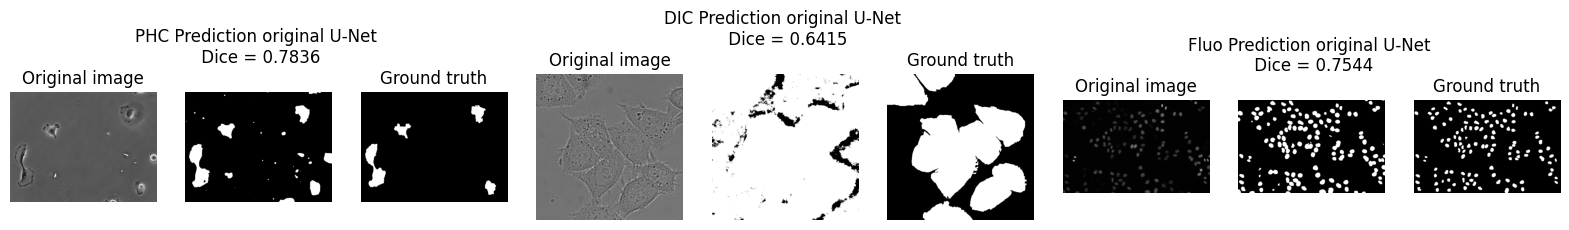

In [50]:
from skimage.morphology import remove_small_objects
from skimage.measure import label
idx = 0

prediction_original1, dice_score1, IoU_score1 = predict(unet, PHC_GT_x_02[idx], PHC_GT_y_02[idx], patch_size=patch_size_original_test, stride=stride_original_test, padding=padding_original_test, image_transforms = image_transforms_test, label_transforms=label_transforms_test,domain_label=2)
prediction_original2, dice_score2, IoU_score2 = predict(unet, DIC_GT_x_02[idx], DIC_GT_y_02[idx], patch_size=patch_size_original_test, stride=stride_original_test, padding=padding_original_test, image_transforms = image_transforms_test, label_transforms=label_transforms_test,domain_label=1)
prediction_original3, dice_score3, IoU_score3  = predict(unet, Fluo_ST_x_02[idx], Fluo_ST_y_02[idx], patch_size=patch_size_original_test, stride=stride_original_test, padding=padding_original_test, image_transforms = image_transforms_test, label_transforms=label_transforms_test,domain_label=0)

plot_images(
    [PHC_GT_x_02[idx], 'Original image'],
    [prediction_original1, f'PHC Prediction original U-Net \n Dice = {np.round(dice_score1,4)}\n'],
    [PHC_GT_y_02[idx]>0, 'Ground truth'],
    [DIC_GT_x_02[idx], 'Original image'],
    [prediction_original2, f'DIC Prediction original U-Net \n Dice = {np.round(dice_score2,4)}\n '],
    [DIC_GT_y_02[idx]>0, 'Ground truth'],
    [Fluo_ST_x_02[idx], 'Original image'],
    [prediction_original3, f'Fluo Prediction original U-Net \n Dice = {np.round(dice_score3,4)}\n'],
    [Fluo_ST_y_02[idx]>0, 'Ground truth']
)

In [ ]:
plot_images1(
    [PHC_GT_x_02[idx], 'Original image'],
    [prediction_original1, f'PHC Prediction original U-Net \n Dice = {np.round(dice_score1,4)}\n'],
    [PHC_GT_y_02[idx]>0, 'Ground truth'],
    [DIC_GT_x_02[idx], 'Original image'],
    [prediction_original2, f'DIC Prediction original U-Net \n Dice = {np.round(dice_score2,4)}\n '],
    [DIC_GT_y_02[idx]>0, 'Ground truth'],
    [Fluo_ST_x_02[idx], 'Original image'],
    [prediction_original3, f'Fluo Prediction original U-Net \n Dice = {np.round(dice_score3,4)}\n'],
    [Fluo_ST_y_02[idx]>0, 'Ground truth']
)

In [52]:

test_scores_original_dice = []
test_scores_original_IoU = []

# For the time being we define the combined set from 5 images in each microscopy as test set. For Fluo, ST is used because GT labels are weird.
x_test=[PHC_GT_x_02[0:5,],DIC_GT_x_02[0:5,],Fluo_ST_x_02[0:5,]]
y_test=[PHC_GT_y_02[0:5,],DIC_GT_y_02[0:5,],Fluo_ST_y_02[0:5,]]
for i in range(len(x_test)):
    for t in range(len(x_test[i])):
        prediction, dice_score,IoU_score = predict(UnetLightningModel.model, x_test[i][t], y_test[i][t], patch_size=patch_size_original_test, stride=stride_original_test, padding=padding_original_test, image_transforms = image_transforms_test, label_transforms=label_transforms_test,domain_label=0)
        test_scores_original_dice.append(dice_score)
        test_scores_original_IoU.append(IoU_score)
print(f'dice score for the test dataset using the original U-Net: {np.mean(test_scores_original_dice)},IoU score: {np.mean(test_scores_original_IoU)}')


dice score for the test dataset using the original U-Net: 0.7596520178587536,IoU score: 0.6159387245587562


## Report

In [ ]:
print(
   f'''
Report\n
hidden_dims  = {hidden_dims}
padding_mode = {padding_mode}
skip_mode    = {skip_mode}
upsampling_mode = {upsampling_mode}
dropout      = {dropout}
batch_size   = {batch_size}
patch_size_original_train = {patch_size_original_train}
stride_original_train = {stride_original_train}
padding_original_train = {padding_original_train}
dice_ratio = {dice_ratio}
domain_loss_ratio = {domain_loss_ratio}

#Data augmentation
execution_probability = {execution_probability}
num_fluo = {num_fluo}
num_dic = {num_dic}
num_phc = {num_phc}
crop_num_fluo= {(len(Fluo_croppeddata[0]))}
crop_num_dic= {(len(DIC_croppeddata[0]))}
crop_num_phc= {(len(PHC_croppeddata[0]))}

#Test setting
patch_size_original_test= {patch_size_original_test}
stride_original_test = {stride_original_test}
padding_original_test = {padding_original_test}
'''
)


Report

hidden_dims  = [32, 64, 128, 256, 512]
padding_mode = valid
skip_mode    = concat
upsampling_mode = transpose
dropout      = 0.2
batch_size   = 8
patch_size_original_train = [460, 460]
stride_original_train = [52, 52]
padding_original_train = [0, 0]
dice_ratio = 0.5
domain_loss_ratio = 0.1

#Data augmentation
execution_probability = 0.7
num_fluo = 2
num_dic = 40
num_phc = 9
crop_num_fluo= 84
crop_num_dic= 4
crop_num_phc= 18

#Test setting
patch_size_original_test= [460, 460]
stride_original_test = [52, 52]
padding_original_test = [200, 200]

